In [1]:
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats
import statsmodels.stats.multitest
import networkx as nx
from tqdm import tqdm

import concurrent.futures
from scipy.stats import mannwhitneyu

from functools import partial
from itertools import product
from functools import partial

import pyBigWig
import pyranges1 as pr
import datasources
from knots_tools import *

In [2]:
ccds_pr, _ = load_cknots_base_data()

# Replication timing

In [3]:
rt_metadata = pd.read_csv('./data/reptiming_metadata.tsv', sep='\t', comment='#')
rt_metadata.columns

Index(['File Download URL', 'Experiment Set Accession', 'Experiment Accession',
       'File Accession', 'Size (MB)', 'md5sum', 'File Type', 'File Format',
       'Bio Rep No', 'Tech Rep No', 'Biosource Type', 'Organism',
       'Related File Relationship', 'Related File', 'Paired End', 'Set Status',
       'File Status', 'Publication', 'Experiment Type', 'Replicate Info',
       'Assay Details', 'Biosource', 'Dataset', 'Condition',
       'In Experiment As', 'Project', 'Generating Lab', 'Experimental Lab',
       'Contributing Lab', 'Notes', 'Open Data URL'],
      dtype='str')

In [4]:
def path_from_fil_url(urls, base_dir= './data/reptiming/', strip=3):
    return (base_dir + urls['File Download URL'].str.rsplit('/').str[-1]).str[:-strip]

_files = rt_metadata.loc[
    (rt_metadata['File Format'] == 'bg') & \
    (rt_metadata['Bio Rep No'] > 0) & \
    (rt_metadata['Tech Rep No'] > 0),
    ['File Download URL', 'Condition', 'Bio Rep No']
]\
    .assign(path = path_from_fil_url)\
    .drop(columns=['File Download URL'])
_files

,Condition,Bio Rep No,path
0,late,1,./data/reptiming/4DNFIS7J9B9X.bedGraph
2,late,2,./data/reptiming/4DNFIT26294Y.bedGraph
4,early,1,./data/reptiming/4DNFI6TILWWX.bedGraph
6,early,2,./data/reptiming/4DNFIIMJQ8NT.bedGraph


In [5]:
reps_data = {}
for irep, repdf in _files.groupby('Bio Rep No'):
    repdf = repdf.set_index('Condition')
    df_E, df_L = [
        pd.read_csv(
            repdf.loc[cond, 'path'],
            sep='\t', names=['Chromosome', 'Start', 'End', cond.upper()[0] + 'v']
        ).set_index(['Chromosome', 'Start', 'End'])
        for cond in ['early', 'late']
    ]
    eps = 0.01
    df = pd.concat([df_E, df_L], axis=1)
    df['RT'] = np.log2((df.Ev + eps) / (df.Lv + eps))
    reps_data[irep] = df
dfc = (reps_data[1] + reps_data[2]) / 2.0
print(dfc.head())
for col in ['Ev', 'Lv', 'RT']:
    print(f'cor {col}: {scipy.stats.pearsonr(reps_data[1][col], reps_data[2][col])}')
dfc_pr = pr.PyRanges(dfc.reset_index())
dfc_pr

                              Ev        Lv        RT
Chromosome Start End                                
chr1       0     5000   0.000000  0.000000  0.000000
           5000  10000  0.000000  0.000000  0.000000
           10000 15000  0.000000  0.000000  0.000000
           15000 20000  0.040923  0.017916  1.032185
           20000 25000  0.000000  0.000000  0.000000
cor Ev: PearsonRResult(statistic=np.float64(0.9512673257906187), pvalue=np.float64(0.0))
cor Lv: PearsonRResult(statistic=np.float64(0.9134300454733121), pvalue=np.float64(0.0))
cor RT: PearsonRResult(statistic=np.float64(0.9438987222861652), pvalue=np.float64(0.0))


,Chromosome,Start,End,Ev,Lv,RT
0,chr1,0,5000,0.000000,0.000000,0.000000
1,chr1,5000,10000,0.000000,0.000000,0.000000
2,chr1,10000,15000,0.000000,0.000000,0.000000
3,chr1,15000,20000,0.040923,0.017916,1.032185
...,...,...,...,...,...,...
617661,chrY,57210000,57215000,0.000000,0.000000,0.000000
617662,chrY,57215000,57220000,0.000000,0.000000,0.000000
617663,chrY,57220000,57225000,0.000000,0.000000,0.000000
617664,chrY,57225000,57227415,0.000000,0.000000,0.000000


In [6]:
ccd2rt = ccds_pr.join_overlaps(dfc_pr, report_overlap_column='Overlap')
ccd2rt

,dataset,Chromosome,ccd_id,Start,End,n_nodes,degree_min,degree_max,degree_mean,closeness_min,...,n_minors,has_minors,density,length,Start_b,End_b,Ev,Lv,RT,Overlap
0,GM12878,chr1,1,979903,1292598,144,1,31,3.833333,0.209064,...,3,True,0.026807,312695,975000,980000,0.992233,0.019797,5.065731,97
0,GM12878,chr1,1,979903,1292598,144,1,31,3.833333,0.209064,...,3,True,0.026807,312695,980000,985000,1.070452,0.081067,3.630287,5000
0,GM12878,chr1,1,979903,1292598,144,1,31,3.833333,0.209064,...,3,True,0.026807,312695,985000,990000,0.621709,0.039593,3.651112,5000
0,GM12878,chr1,1,979903,1292598,144,1,31,3.833333,0.209064,...,3,True,0.026807,312695,990000,995000,0.730872,0.028754,4.278609,5000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9100,WTC11,chrX,2,2791775,155651137,22716,1,40,2.810178,0.041031,...,0,False,0.000124,152859362,155635000,155640000,0.168430,0.298829,-0.830576,5000
9100,WTC11,chrX,2,2791775,155651137,22716,1,40,2.810178,0.041031,...,0,False,0.000124,152859362,155640000,155645000,0.149884,0.343618,-1.145127,5000
9100,WTC11,chrX,2,2791775,155651137,22716,1,40,2.810178,0.041031,...,0,False,0.000124,152859362,155645000,155650000,0.167523,0.178169,-0.103945,5000
9100,WTC11,chrX,2,2791775,155651137,22716,1,40,2.810178,0.041031,...,0,False,0.000124,152859362,155650000,155655000,0.160064,0.298382,-0.873465,1137


In [7]:
ccd2rt['RTw'] = ccd2rt.RT / ccd2rt.Overlap
rt_agg = ccd2rt.groupby(['has_minors', 'Chromosome', 'ccd_id']).agg(
    sumRTw = pd.NamedAgg('RTw', 'sum'),
    sumOverlap = pd.NamedAgg('Overlap', 'sum'),
    length_bp = pd.NamedAgg('length', 'first'),
    Start = pd.NamedAgg('Start', 'first'),
    End = pd.NamedAgg('End', 'first')
)
rt_agg['RT'] = 1e6 * rt_agg.sumRTw / rt_agg.sumOverlap
rt_agg

sumRTw  sumOverlap  length_bp      Start  \
has_minors Chromosome ccd_id                                               
False      chr1       1       0.070172      270516      73231     838780   
                      2       0.144508      890451      48113    1396161   
                      3       0.192001      862882     188573    2194421   
                      4       0.196803     1789830     136198    2414292   
                      5       0.042456      392457      33954    2554288   
...                                ...         ...        ...        ...   
True       chrX       29     -0.055273     1177117    1177117   49146731   
                      33     -0.370998     5451898    5451898   52603285   
                      36     -0.056528     1151247    1151247   64800817   
                      38     -0.044181      332194     332194  115324718   
                      43     -0.050405      803116     803116  131821091   

                                    End        RT  
has_minors Chromosome ccd_id                       
False      chr1       1          912011  0.259402  
                      2         1444274  0.162286  
                      3         2382994  0.222512  
                      4         2550490  0.109956  
                      5         2588242  0.108179  
...                                 ...       ...  
True       chrX       29       50323848 -0.046957  
                      33       58055183 -0.068049  
                      36       65952064 -0.049101  
                      38      115656912 -0.132996  
                      43      132624207 -0.062762  

[3379 rows x 6 columns]

Mann-Whitney U test: statistic=1301925.0000, p-value=0.000000 (data: RT). Median: non-linked=0.0767, linked=0.0051


/home/michade/proj/knots/intrinsic_linking/knots_tools.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['non-linked', 'linked'])


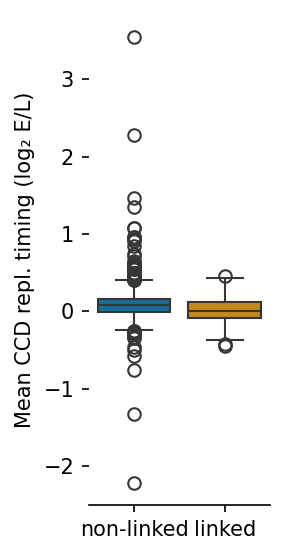

In [8]:
rt_agg_clip = rt_agg[rt_agg.length_bp < 2e7]

_, axs = plt.subplots(1, 1, figsize=(2, 3.8), dpi=150)
compare_boxplot(rt_agg_clip, axs, 'RT', 'Mean CCD repl. timing (log₂ E/L)');
plt.tight_layout()
# plt.savefig('./results/svg/reptime.svg')

In [9]:
def rank_biserial(x, y):
    u, p = mannwhitneyu(x, y, alternative="two-sided")

    n1 = len(x)
    n2 = len(y)

    rbc = 2 * u / (n1 * n2) - 1

    print(f"U = {u}")
    print(f"p = {p}")
    print(f"Rank-biserial correlation = {rbc:.3f}")

print ("Rank-biserial correlation for RT between linked and non-linked CCDs:")
rank_biserial(
    rt_agg_clip.query('has_minors == False')['RT'],
    rt_agg_clip.query('has_minors == True')['RT']
)

Rank-biserial correlation for RT between linked and non-linked CCDs:
U = 1301925.0
p = 3.8950798102488125e-31
Rank-biserial correlation = 0.271
